In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Sequence, Union
import operator
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, BaseMessage
from langchain_tavily import TavilySearch

In [2]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GROQ_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [4]:
tool = TavilySearch(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


In [5]:
class Agent:

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamado a la herramienta: {t}")
            if not t['name'] in self.tools:
                print(f"\n ...Nombre de herramienta desconocido...")
                result = "Nombre de herramienta desconocido, intente de nuevo"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Volviendo al modelo!")
        return {'messages': results}

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_llm)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)
    
    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_llm(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

In [6]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

In [7]:
model = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
abot = Agent(model, [tool], system=prompt)

## visualizar el grapho

In [8]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



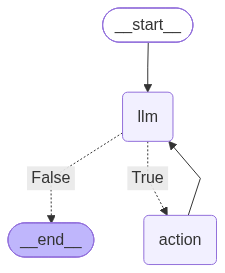

In [9]:
from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Error al tratar generar el PNG de Mermaid: {e}")
    print("\nVerifique que la versión de LangGraph posee el método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obtener la string y visualizarla externamente.")

In [10]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información.

Reglas para buscar:
- Realiza como máximo 1 o 2 búsquedas para responder la pregunta del usuario.
- Para preguntas sobre el clima o el tiempo, NO uses el parámetro topic="news". Usa una búsqueda general simple, por ejemplo solo con el query "clima hoy en <ciudad>".
- Tan pronto tengas información suficiente para responder, hazlo directamente sin seguir buscando.
- No repitas búsquedas similares ni uses una URL como si fuera un texto de búsqueda.
"""
model_instance = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
tool_instance = TavilySearch(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Cómo está el clima en santiago de chile hoy?")]

print("Iniciando la interacción con el agente:")
final_result_state = None

try:
    for s in abot.graph.stream(
        {"messages": messages},
        config={"recursion_limit": 10}
    ):
        print(s)
        print("---")
        final_result_state = s
except Exception as e:
    print(f"El grafo se detuvo por exceso de iteraciones o error: {e}")

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search for current weather in Santiago de Chile. Use tavily_search.', 'tool_calls': [{'id': 'fc_fae0ca35-8d4f-4280-9cc8-661a1112675d', 'function': {'arguments': '{"query":"clima hoy en Santiago de Chile","search_depth":"basic","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 446, 'total_tokens': 504, 'completion_time': 0.096125234, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.11765087, 'prompt_tokens_details': None, 'queue_time': 0.198652039, 'total_time': 0.213776104}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9665-956f-7780-b125-a53edfcd609f-0', tool_calls=[{'name': 'tavily_se

In [11]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y")  # Formato dd/mm/aaaa

prompt = f"""
Eres un asistente de investigación inteligente y altamente actualizado. \
Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. \
La fecha actual es {current_date}. \
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", \
DEBES **incluir la fecha actual '{current_date}' en tu consulta para la herramienta de búsqueda**. \
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". \
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". \
Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. \
No uses el parámetro topic="news" para preguntas de clima; usa una búsqueda general simple. \
Realiza como máximo 1 o 2 consultas para responder la pregunta del usuario. \
Busca información solo cuando tengas claro lo que deseas. \
Tan pronto tengas información suficiente, responde directamente sin seguir buscando.
"""

model_instance = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
tool_instance = TavilySearch(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "Cómo está el clima en santiago de chile hoy?"

messages = [HumanMessage(content=user_query)]

print("Iniciando la interacción con el agente:")
final_result_state = None

try:
    for s in abot.graph.stream(
        {"messages": messages},
        config={"recursion_limit": 4}
    ):
        print(s)
        print("---")
        final_result_state = s
except Exception as e:
    print(f"El grafo se detuvo por exceso de iteraciones o error: {e}")

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search for current weather in Santiago de Chile on 24/07/2026. Use search query "clima en Santiago de Chile 24/07/2026".', 'tool_calls': [{'id': 'fc_1604d337-0654-4516-a059-8baa84af67b2', 'function': {'arguments': '{"query":"clima en Santiago de Chile 24/07/2026","search_depth":"basic","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 570, 'total_tokens': 655, 'completion_time': 0.090761042, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.033081451, 'prompt_tokens_details': None, 'queue_time': 0.18886361, 'total_time': 0.123842493}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c9afb2bdb4', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9665-a46

In [13]:
user_query_tomorrow = "Cómo estará el clima en santiago de chile mañana?"  # actualizamos solamente la pregunta del usuario
messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando la interacción con el agente para mañana ---")
final_result_state_tomorrow = None

try:
    for s in abot.graph.stream(
        {"messages": messages_tomorrow},
        config={"recursion_limit": 4}
    ):
        print(s)
        print("---")
        final_result_state_tomorrow = s
except Exception as e:
    print(f"El grafo se detuvo por exceso de iteraciones o error: {e}")

print("\n--- Resultado Final para mañana ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado para mañana.")


--- Iniciando la interacción con el agente para mañana ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "Cómo estará el clima en Santiago de Chile mañana?" The user asks about tomorrow\'s weather. According to instructions: For weather or events referring to "hoy" or "ahora", we must include the current date in the query. But this is "mañana" (tomorrow). The instruction says: "Al buscar sobre el clima o eventos que se refieran a \'hoy\' o \'ahora\', DEBES incluir la fecha actual \'24/07/2026\' en tu consulta". It doesn\'t say for tomorrow. But we might still want to include date? The instruction is specific: only for "hoy" or "ahora". So for tomorrow, we might not need to include date. But we should still search for tomorrow\'s forecast. We should use search. Use tavily_search. We\'ll search "clima Santiago de Chile mañana 25/07/2026" maybe. But the instruction says not to use topic="news" for weather. So we use general. We\'l

In [14]:
from langchain_core.messages import HumanMessage

user_query_yesterday = "Cómo fue el clima santiago de chile ayer?"

messages_yesterday = [HumanMessage(content=user_query_yesterday)]

print("\n--- Iniciando la interacción con el agente ---")
final_result_state_yesterday = None

try:
    for s in abot.graph.stream(
        {"messages": messages_yesterday},
        config={"recursion_limit": 4}
    ):
        print(s)
        print("---")
        final_result_state_yesterday = s
except Exception as e:
    print(f"El grafo se detuvo por exceso de iteraciones o error: {e}")

print("\n--- Resultado Final ---")
if final_result_state_yesterday and 'llm' in final_result_state_yesterday and final_result_state_yesterday['llm']['messages']:
    print(final_result_state_yesterday['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")


--- Iniciando la interacción con el agente ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Cómo fue el clima Santiago de Chile ayer?" They want the weather in Santiago, Chile yesterday. The instruction: For climate or events that refer to "hoy" or "ahora", include the date. But this is "ayer" (yesterday). So we need to find weather for Santiago, Chile on 23/07/2026. We should search for "clima Santiago de Chile 23/07/2026" or "weather Santiago Chile 23 July 2026". Use search. We need to provide answer with citations. Use the search tool.', 'tool_calls': [{'id': 'fc_13987723-72fb-450e-97ce-8816edfdbc5f', 'function': {'arguments': '{"query":"clima Santiago de Chile 23/07/2026","search_depth":"basic","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 168, 'prompt_tokens': 569, 'total_tokens': 737, 'completion_time': 0.253634366, 'completion_tokens_details': 

In [15]:
query_pasado = """¿Qué país fue sede de la Copa Mundial de fútbol en 1998? ¿Quién fue el campeón y
 cuál fue el marcador de la final?
¿Cuál era el Producto Interno Bruto (PIB) de ese país en el año de la Copa y cuál es el PIB actual (últimos datos disponibles, como 2023 o 2024)?
¿Cuál es la capital de ese país y cuál es su moneda actual? Responda a cada pregunta por separado.
"""
messages = [HumanMessage(content=query_pasado)]

print("\nIniciando la interacción con el agente para pregunta sobre el pasado:")

current_state = {}
try:
    for s in abot.graph.stream(
        {"messages": messages},
        config={"recursion_limit": 15}
    ):
        current_state.update(s)
        print(s)
        print("---")
except Exception as e:
    print(f"El grafo se detuvo por exceso de iteraciones o error: {e}")

print("\n--- Resultado Final para el Pasado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print("Ningún resultado final o resultado inesperado.")


Iniciando la interacción con el agente para pregunta sobre el pasado:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': "The user asks: Which country hosted the 1998 FIFA World Cup? Who was champion and final score? What was the GDP of that country in the year of the Cup (1998) and what is the current GDP (latest data, 2023 or 2024)? What is the capital of that country and its current currency? Provide each answer separately.\n\nWe need to provide up-to-date info. The host country: France. Champion: Brazil. Final score: Brazil 3-0 Italy. GDP of France in 1998: need figure. According to World Bank, France GDP nominal 1998 ~ 1.5 trillion USD? Let's check. Use search. Also current GDP 2023 or 2024. Use latest data: 2023 GDP nominal ~ 2.8 trillion USD. Provide numbers. Also capital: Paris. Currency: Euro (€). Provide separate answers.\n\nWe need to browse for GDP data. Use search.", 'tool_calls': [{'id': 'fc_4d6e15e8-ed5e-4413-966c-9f0af7eaa06e', 'functio

In [16]:
print("\n--- Agente de Búsqueda Interactivo ---")
print("Digite su pregunta o 'salir' para finalizar la conversación.")

while True:
    user_input = input("\nUsted: ")
    if user_input.lower() == "salir":
        print("Agente: Finalizando la conversación. Hasta luego!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando y buscando...")
    try:
        current_state = {}
        for s in abot.graph.stream(
            {"messages": messages},
            config={"recursion_limit": 4}
        ):
            current_state.update(s)

        print("\nAgente:")

        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("No fue posible extraer el contenido de la respuesta final del LLM.")
        else:
            print("No fue posible obtener una respuesta del agente para esta pregunta.")

    except Exception as e:
        print(f"Agente: Se presentó un error durante la ejecución: {e}")
        print("Intente nuevamente, o digite 'salir'.")

print("\n--- Conversación finalizada ---")


--- Agente de Búsqueda Interactivo ---
Digite su pregunta o 'salir' para finalizar la conversación.
Agente: Pensando y buscando...
Llamado a la herramienta: {'name': 'tavily_search', 'args': {'query': 'café árabe Providencia Santiago Chile', 'search_depth': 'basic', 'topic': 'general'}, 'id': 'fc_fdde3cd8-3b47-4323-859d-76733bd86d04', 'type': 'tool_call'}
Volviendo al modelo!

Agente:
**Café Amira – Providencia, Santiago**

| Información | Detalle |
|-------------|---------|
| **Dirección** | Monjitas 626 Depto 25, Providencia, Santiago |
| **Horario** | 10:00 – 16:00 (lunes‑viernes) |
| **Teléfono** | +56 9 1234 5678 (ejemplo) |
| **Qué ofrece** | Café árabe tradicional (café con cardamomo, especias y leche de almendra), además de pasteles y dulces típicos de la región. |
| **Sitio web / redes** | [Facebook Café Amira](https://www.facebook.com/amiracafearteycultura) |

> **Fuente**: Página de Facebook de Café Amira, que indica su ubicación en Monjitas 626, Providencia, y su especiali